# Generate the graphics

The final code was consolidated, tested both here and on the RaspPi. Except for a very 
specific missing feature of `tesseract` on the "pi". The capture and storage works like a charm.

Now that we have this data we need to up the graphics game.

The plan is as follows. The pi runs the capture software as part of a `cron` task. The wind data 
screen is updated every 15 minutes while the wave data is updated every 20. The idea is to replace
the wind graphic with one that tracks the wind and wave direction.  Maybe add a visual on the confluence
of the direction and strength of the wind and the waves.  The data is held in a circular buffer that keeps 
data going back 48 hours.  We generate a new wind graph every time we update our dataset. 

 - Consider shrinking the tide graphic a bit in the y direction to make room for a busier wind/wave graph?
 - Try different methods of illustrating the wind/wave strength/direction.

In [ ]:
!scp -p pi@10.110.110.183:WeatherKiosk/resources/wave_data.csv tmp/execrocks_wave_data.csv
!scp -p pi@10.110.110.183:WeatherKiosk/resources/wind_data.csv tmp/execrocks_wind_data.csv
!ls -l tmp/*.csv

wave_data.csv                                 100%   22KB   2.1MB/s   00:00    
wind_data.csv                                 100%   37KB   1.5MB/s   00:00    
ls: cannot access '*.csv': No such file or directory


## Preliminary Look at Wind

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

windDF = pd.read_csv("tmp/execrocks_wind_data.csv", index_col=0, parse_dates=True)
windDF.tail()


,WindSpeedAvg [kts],WindSpeedGst [kts],WindSpeedAvg [mph],WindSpeedGst [mph],WindSpeedAvg [m/s],WindSpeedGst [m/s],WindDir [°],AirTemp [°F],AirTemp [°C],BaromPres [mmHg],BaromPres [mB],DewPoint [°F],DewPoint [°C],RelHum [%],WindSpeedM24 [kt],WindDirM24 [°],WindTimeM24
TimeStamp,,,,,,,,,,,,,,,,,
2026-02-12 17:11:00-05:00,16.5,24.9,19.0,28.7,8.5,12.8,295.0,33.4,0.8,29.96,1014.73,40.4,4.7,58.3,32.2,270.0,2026-02-11 23:41:00-05:00
2026-02-12 17:26:00-05:00,15.6,21.8,18.0,25.1,8.0,11.2,293.0,32.9,0.5,29.97,1014.93,40.4,4.7,60.6,32.2,270.0,2026-02-11 23:41:00-05:00
2026-02-12 17:41:00-05:00,14.2,18.6,16.3,21.5,7.3,9.6,296.0,32.8,0.5,29.98,1015.20,40.4,4.7,60.9,32.2,270.0,2026-02-11 23:41:00-05:00
2026-02-12 18:11:00-05:00,11.5,17.3,13.3,19.9,5.9,8.9,308.0,32.4,0.2,29.99,1015.51,40.4,4.7,61.9,32.2,270.0,2026-02-11 23:41:00-05:00
2026-02-12 18:26:00-05:00,14.4,20.4,16.6,23.5,74.0,10.5,310.0,32.4,0.2,29.99,1015.63,40.4,4.7,60.1,32.2,270.0,2026-02-11 23:41:00-05:00


In [46]:
# Sometimes the OCR drops the decimal point.  This is afilter to catch these errors.
# First drop nas
if len(windDF) > len(windDF.dropna()):
    print(f"NaN values dropped: {len(windDF) - len(windDF.dropna())}")
    windDF = windDF.dropna()

def errorFactor(dataFrame, colA, colB, spUnits=1.0):
    """
    spUnits mps to knts = 1.94384, spUnits mph to knts = 0.868976, spUnits mps to mph = 2.23694
    spUnits m to ft = 3.28084, spUnits ft to m = 0.3048
    Sometimes the OCR drops the decimal point.  This is a filter to catch these errors.
    The sensors report the same value, but in different units.  If the values are close, 
    then the error factor is small.  If the values are far apart, then the error factor is large 
    and a candidate for review. The cool thing is that the error is either 10 or 100. So the fix is easy
    """
    return np.abs(dataFrame[colA] - (dataFrame[colB] * spUnits))/dataFrame[colA]

print(f"error values in windDF:")
windDF['WindSpeedAvg [kts]'][errorFactor(windDF, 'WindSpeedAvg [kts]', 'WindSpeedAvg [m/s]', 1.94384)>0.05]


error values in windDF:


TimeStamp
2026-02-10 03:26:00-05:00     9.2
2026-02-10 09:56:00-05:00     0.9
2026-02-10 11:26:00-05:00     0.9
2026-02-10 11:56:00-05:00     0.7
2026-02-12 18:26:00-05:00    14.4
Name: WindSpeedAvg [kts], dtype: float64

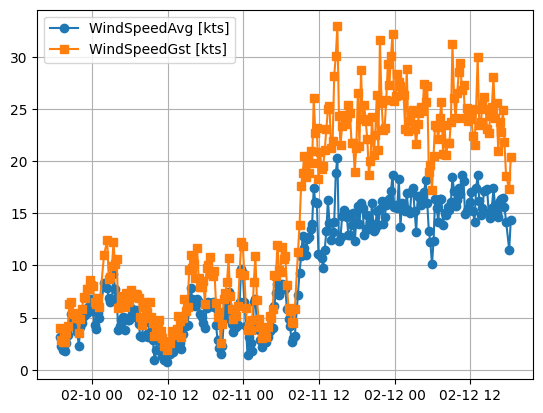

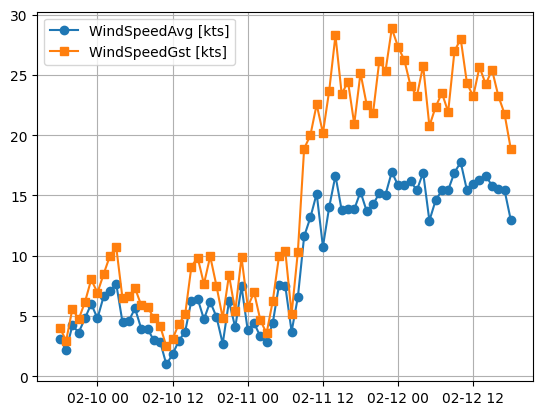

In [62]:
#tempDF = windDF.dropna()
#tempDF.plot('Timestamp.1',['WindSpeedAvg [kts]', 'WindSpeedGst [kts]'], kind='scatter')

windDF = windDF.dropna()

timeIdx  = windDF.index.to_numpy()
windsp   = windDF['WindSpeedAvg [kts]'].to_numpy()
windgs   = windDF['WindSpeedGst [kts]'].to_numpy()

plt.plot(timeIdx, windsp, label='WindSpeedAvg [kts]', marker='o')
plt.plot(timeIdx, windgs, label='WindSpeedGst [kts]', marker='s')
plt.grid(True)
plt.legend()
plt.show()

windRSDF = windDF.select_dtypes(include='number').resample('1h').mean()
timeIdx  = windRSDF.index.to_numpy()
windsp   = windRSDF['WindSpeedAvg [kts]'].to_numpy()
windgs   = windRSDF['WindSpeedGst [kts]'].to_numpy()

plt.plot(timeIdx, windsp, label='WindSpeedAvg [kts]', marker='o')
plt.plot(timeIdx, windgs, label='WindSpeedGst [kts]', marker='s')
plt.grid(True)
plt.legend()
plt.show()
#windRSDF


## Preliminary Look at Waves

In [41]:
waveDF = pd.read_csv("tmp/execrocks_wave_data.csv", index_col=0, parse_dates=True)
waveDF.tail()

,WaveHgtSig [ft],WaveHgtMax [ft],WaveHgtSig [m],WaveHgtMax [m],WaveDir [°],WavPerAvg [s],WavPerDom [s],WaveHgt24 [ft],WaveDirM24 [°],WavePerAvgM24 [s],WavePerDomM24 [s],WaveTimeM24
TimeStamp,,,,,,,,,,,,
2026-02-12 17:16:00-05:00,1.00,1.76,0.31,0.54,314.0,2.2,22.0,2.51,44.0,2.4,2.4,2026-02-12 10:16:00-05:00
2026-02-12 17:36:00-05:00,0.85,1.49,0.26,0.45,304.0,2.2,22.0,2.51,44.0,2.4,2.4,2026-02-12 10:16:00-05:00
2026-02-12 17:56:00-05:00,0.69,1.22,0.21,0.37,287.0,24.0,22.0,2.51,44.0,2.4,2.4,2026-02-12 10:16:00-05:00
2026-02-12 18:16:00-05:00,0.44,0.77,0.13,0.24,267.0,24.0,2.0,2.51,44.0,2.4,2.4,2026-02-12 10:16:00-05:00
2026-02-12 18:36:00-05:00,0.43,0.76,0.13,0.23,37.0,2.0,2.0,2.51,44.0,2.4,2.4,2026-02-12 10:16:00-05:00


In [48]:
# Sometimes the OCR drops the decimal point.  This is afilter to catch these errors.
# First drop nas
if len(waveDF) > len(waveDF.dropna()):
    print(f"NaN values dropped: {len(waveDF) - len(waveDF.dropna())}")
    waveDF = waveDF.dropna()

print(f"error values in waveDF (len(waveDF)):")
waveDF['WaveHgtSig [ft]'][errorFactor(waveDF, 'WaveHgtSig [ft]', 'WaveHgtSig [m]', 3.28084)>0.1]

error values in waveDF (len(waveDF)):


TimeStamp
2026-02-09 18:56:00-05:00    0.05
2026-02-09 19:16:00-05:00    0.04
2026-02-09 21:36:00-05:00    0.11
2026-02-09 21:56:00-05:00    0.02
2026-02-09 22:16:00-05:00    0.02
                             ... 
2026-02-11 07:16:00-05:00    0.01
2026-02-11 08:36:00-05:00    0.08
2026-02-11 09:36:00-05:00    0.02
2026-02-11 11:16:00-05:00    0.11
2026-02-12 09:36:00-05:00    2.11
Name: WaveHgtSig [ft], Length: 83, dtype: float64

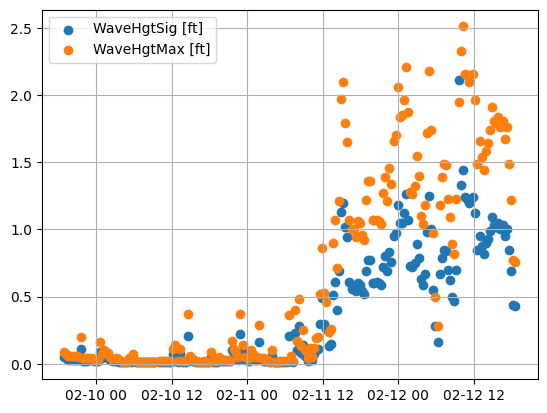

In [51]:
#tempDF = windDF.dropna()
#tempDF.plot('Timestamp.1',['WindSpeedAvg [kts]', 'WindSpeedGst [kts]'], kind='scatter')

timeIdx  = waveDF.dropna().index.to_numpy()
waveht   = waveDF.dropna()['WaveHgtSig [ft]'].to_numpy()
wavemx   = waveDF.dropna()['WaveHgtMax [ft]'].to_numpy()

plt.scatter(timeIdx, waveht, label='WaveHgtSig [ft]')
plt.scatter(timeIdx, wavemx, label='WaveHgtMax [ft]')
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
# tempDF = waveDF.dropna()
# tempDF.plot('Timestamp.1',['WaveHgtSig [ft]', 'WaveHgtMax [ft]'], kind='scatter')


timeIdx  = waveDF.dropna().index.to_numpy()
wavesp   = waveDF.dropna()['WaveHgtSig [ft]'].to_numpy()
sel = wavesp>10
wavesp[sel] = wavesp[sel]/100

wavegs   = waveDF.dropna()['WaveHgtMax [ft]'].to_numpy()
sel = wavegs>10
wavegs[sel] = wavegs[sel]/100

plt.scatter(timeIdx, wavesp)
plt.scatter(timeIdx, wavegs)
plt.grid(True)

plt.show()

In [ ]:

timeIdx  = waveDF.dropna().index.to_numpy()

wavepr   = waveDF.dropna()['WavPerAvg [s]'].to_numpy()
sel = wavepr>10
wavepr[sel] = wavepr[sel]/10

wavedm   = waveDF.dropna()['WavPerDom [s]'].to_numpy()
sel = wavedm>10
wavedm[sel] = wavedm[sel]/10

plt.scatter(timeIdx, wavepr)
plt.scatter(timeIdx, wavedm)
plt.grid(True)

plt.show()

---
## Let's Build Graphics

In [63]:
#!/usr/bin/python3
#
from datetime import datetime, date, time, timedelta
import logging
from pytz import timezone  # should already be part of pandas but it doesn't hurt to do it again.

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.transforms
import matplotlib.dates as mdates

EST = timezone('America/New_York')
UTC = timezone('UTC')

windDF = pd.read_csv("tmp/execrocks_wind_data.csv", index_col=0, parse_dates=True)
windDF.head()


,WindSpeedAvg [kts],WindSpeedGst [kts],WindSpeedAvg [mph],WindSpeedGst [mph],WindSpeedAvg [m/s],WindSpeedGst [m/s],WindDir [°],AirTemp [°F],AirTemp [°C],BaromPres [mmHg],BaromPres [mB],DewPoint [°F],DewPoint [°C],RelHum [%],WindSpeedM24 [kt],WindDirM24 [°],WindTimeM24
TimeStamp,,,,,,,,,,,,,,,,,
2026-02-09 18:56:00-05:00,3.1,4.0,3.6,4.6,1.6,2.1,308.0,29.5,-1.4,30.19,1022.41,40.4,4.7,59.2,29.8,316.0,2026-02-08 23:41:00-05:00
2026-02-09 19:11:00-05:00,2.3,2.9,2.7,3.4,1.2,1.5,298.0,29.5,-1.4,30.19,1022.48,40.4,4.7,56.3,29.8,316.0,2026-02-08 23:41:00-05:00
2026-02-09 19:26:00-05:00,1.9,2.7,2.1,32.0,1.0,1.4,323.0,29.5,-1.4,30.19,1022.36,40.4,4.7,54.2,29.8,316.0,2026-02-08 23:41:00-05:00
2026-02-09 19:41:00-05:00,1.8,2.7,2.1,3.2,0.9,1.4,332.0,29.4,-1.4,30.19,1022.27,40.4,4.7,53.8,29.8,316.0,2026-02-08 23:41:00-05:00
2026-02-09 19:56:00-05:00,2.6,3.5,3.0,4.1,1.3,1.8,336.0,29.3,-1.5,30.19,1022.31,40.4,4.7,52.4,29.8,316.0,2026-02-08 23:41:00-05:00


In [87]:

# direction indexer
def windDirection(ang):
    labels = {
      'N': (-11.25, 11.25), 'NNE': (11.25, 33.75),   'NE': (33.75, 56.25),   'ENE': (56.25, 78.75),
      'E': (78.75, 101.25), 'ESE': (101.25, 123.75), 'SE': (123.75, 146.25), 'SSE': (146.25, 168.75),
      'S': (168.75, 191.25),'SSW': (191.25, 213.75), 'SW': (213.75, 236.25), 'WSW': (236.25, 258.75),
      'W': (258.75, 281.25),'WNW': (281.25, 303.75), 'NW': (303.75, 326.25), 'NNW': (326.25, 348.75),
    }
    for tag, (min_ang, max_ang) in labels.items():
        if min_ang < ang <= max_ang:
            return tag
    return 'Unknown'

def augmentWindData(windDF):
    """
    The original form pulled in the data and then augmented the columns with annotation information"""
    # now = datetime.now(tz=EST)

    # Local function to create a timezone-aware datetime object from the dataframe row
    def createDateTimeObj(row):
        return datetime(int(row['#YY']), int(row['MM']), int(row['DD']), int(row['hh']), int(row['mm']), tzinfo=UTC).astimezone(EST)

    # windDF['DateTime'] = windDF[['#YY','MM','DD','hh','mm']].apply(lambda dt: datetime(dt['#YY'], dt['MM'], dt['DD'], dt['hh'], dt['mm'], tzinfo=UTC).astimezone(EST), axis=1)
    windDF['DateTime'] = windDF.index
    windDF['Time'] = windDF['DateTime'].apply(lambda t: t.time())  # break the time and date fields out for graphing purposes
    windDF['Date'] = windDF['DateTime'].apply(lambda d: d.date())

    # We need to average the components rather than the angles when resamping.
    windDF['WdirSin'] = np.sin(np.radians(windDF['WindDir [°]']))
    windDF['WdirCos'] = np.cos(np.radians(windDF['WindDir [°]']))

    windDF = windDF[['DateTime', 'Time', 'Date', 'WindDir [°]', 'WindSpeedAvg [kts]', 'WindSpeedGst [kts]', 'AirTemp [°F]', 'WdirSin', 'WdirCos']]
    sel = windDF['WindSpeedAvg [kts]'] > 100
    windDF.loc[sel, 'WindSpeedAvg [kts]'] = windDF.loc[sel, 'WindSpeedAvg [kts]'] / 100

    sel = windDF['WindSpeedGst [kts]'] > 100
    windDF.loc[sel, 'WindSpeedGst [kts]'] = windDF.loc[sel, 'WindSpeedGst [kts]'] / 100    
    
    windDF = windDF.set_index('DateTime')
    return windDF

def makeWindGraph(windDF, whereFrom=""):
    if len(windDF) < 16:
        raise BaseException('Not enough points')

    # imageRef = pathToResources + 'tmp/' +  'windGraph.png' # fetch locally (way faster on a pi)
    imageRef = 'tmp/' +  'windGraph.png' # fetch locally (way faster on a pi)
    fig, ax = plt.subplots(figsize=(8, 4))

    tme = windDF.index
    wspd = windDF['WindSpeedGst [kts]'] # windDF['WSPD']
    mxsp = windDF['WindSpeedGst [kts]'] # windDF['GST']

    # speed in kts.
    ax.plot(tme, wspd, 'bo-', alpha=0.8)
    ax.plot(tme, mxsp, 'ro-', alpha=0.8)

    # Plot direction arrows
    dirDF = windDF.resample('h').agg({'WdirCos':'mean', 'WdirSin':'mean'})
    yloc = 5.0 * np.ones(dirDF.shape[0])
    skp = max(1, windDF.shape[0]//64)  # Aim for about 16 arrows, but at least 1
    (cosines, sines) = (dirDF['WdirCos'], dirDF['WdirSin'])
    ax.quiver(dirDF.index[::skp], yloc[::skp], sines[::skp], cosines[::skp],
                angles='uv', color='Green', alpha=0.6, pivot='middle')

    # Plot direction arrows
    yloc = 3.0 * np.ones(windDF.shape[0])
    # we stored the direction components so the averages would be modulo 360 (or 2pi)
    #    The average between 10 and 350 should be 0 (or 360) NOT 180.
    # An arrow every skp step
    skp = max(1, windDF.shape[0]//16)  # Aim for about 16 arrows, but at least 1
    (cosines, sines) = (windDF['WdirCos'], windDF['WdirSin'])
    ax.quiver(tme[::skp], yloc[::skp], sines[::skp], cosines[::skp],
                angles='uv', color='DodgerBlue', alpha=0.6, pivot='middle')

    # Set the axis labels
    # ax.set_xlabel('Date and Time', fontsize=10, fontstyle='italic', color='SlateGray')  #obvious don't need it.
    ax.set_ylabel('Wind Speed [kts]', fontsize=8, fontstyle='italic', color='SlateGray')

    #Fix the time axis
    ax.xaxis.set_major_locator(mdates.DayLocator(tz=EST))
    ax.xaxis.set_minor_locator(mdates.HourLocator(interval=4, tz=EST))
    ax.xaxis.set_tick_params(which='minor', labelsize=8, rotation=45)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a, %b %d', tz=EST))
    ax.xaxis.set_minor_formatter(mdates.DateFormatter('%H:%M', tz=EST))

    dx = 0.; dy = -10/72.
    offset = matplotlib.transforms.ScaledTranslation(dx, dy, fig.dpi_scale_trans)
    # Create offset transform by 5 points in x direction
    for label in ax.xaxis.get_majorticklabels():
        label.set(horizontalalignment='center', color='darkred', fontweight='bold')
        label.set_transform(label.get_transform() + offset)

    for label in ax.xaxis.get_minorticklabels():
        label.set(horizontalalignment='center', color='darkred')

    ax.grid(True, which='major', linewidth=2, axis='both', alpha=0.7)
    ax.grid(True, which='minor', linestyle='--', axis='both', alpha = 0.5)
    ax.set_ylim(bottom=0.0)

    # where did this come from?
    plt.text(0.99, 0.96, f"{whereFrom}",
          horizontalalignment='right', verticalalignment='center',
          transform=ax.transAxes, color='gray', alpha=0.6 )

    ##
    # Put a current conditions slug at the top
    tme = windDF.index[-1]
    wspd = np.round(windDF['WindSpeedAvg [kts]'].to_numpy()[-1],1)
    mxsp = np.round(windDF['WindSpeedGst [kts]'].to_numpy()[-1],1)
    if mxsp != mxsp:
        mxsp = '-'
    
    temp = windDF['AirTemp [°F]'].to_numpy()[-1]
    wdir = windDF['WindDir [°]'].to_numpy()[-1]
    
    howold = datetime.now(tz=EST)-tme
    oldmin = np.int32(howold.total_seconds()/60)
    # oldhrs = np.int32(old.total_seconds()/3600)
    
    print(f"{tme}, {oldmin} min, {wspd} mph, {mxsp} mph, {wdir:4.0f}°T, {temp}°C")
    # logging.debug(f"{tme}, {oldhrs}:{oldmin} old, {wspd} mph, {mxsp} mph, {wdir:4.0f}°T, {temp}°C")

    plt.text(0.99, 0.90, f"Last readings spd:{wspd}, max:{mxsp}, dir:{windDirection(wdir)}",
          horizontalalignment='right', verticalalignment='center',
          transform=ax.transAxes, color='blue', alpha=0.6 )
    if oldmin > 40:
        plt.text(0.99, 0.84, f"Warning {oldmin} minutes old",
              horizontalalignment='right', verticalalignment='center',
              transform=ax.transAxes, color='darkred', alpha=0.6 )

    #   fig.show()
    fig.savefig(imageRef, bbox_inches='tight', transparent=True)
    plt.close(fig)


In [88]:
windDF = pd.read_csv("tmp/execrocks_wind_data.csv", index_col=0, parse_dates=True)
newWindDF = augmentWindData(windDF)

# newWindDF.head()

# agg_map = {'WdirCos':'mean', 'WdirSin':'mean'}
# dirDF = windDF.resample('h').agg(agg_map)
# dirDF.head()

makeWindGraph(newWindDF, whereFrom="Execution Rocks")

import PIL.Image as Image
import matplotlib.pyplot as plt

img = Image.open('tmp/windGraph.png')
img.show()

2026-02-12 18:26:00-05:00, 264 min, 14.4 mph, 20.4 mph,  310°T, 32.4°C


CinnamonDesktop-Message: 22:50:58.607: Ignoring thumbnailer with missing binary: 'xreader-thumbnailer'


In [ ]:
windDF.tail()

,WindSpeedAvg [kts],WindSpeedGst [kts],WindSpeedAvg [mph],WindSpeedGst [mph],WindSpeedAvg [m/s],WindSpeedGst [m/s],WindDir [°],AirTemp [°F],AirTemp [°C],BaromPres [mmHg],...,DewPoint [°C],RelHum [%],WindSpeedM24 [kt],WindDirM24 [°],WindTimeM24,DateTime,Time,Date,WdirSin,WdirCos
TimeStamp,,,,,,,,,,,,,,,,,,,,,
2026-02-10 13:41:00-05:00,3.9,5.2,4.4,6.0,2.0,2.7,330.0,29.5,-1.4,30.03,...,4.7,58.3,22.5,315.0,2026-02-09 14:11:00-05:00,2026-02-10 13:41:00-05:00,13:41:00,2026-02-10,-0.500000,0.866025
2026-02-10 13:56:00-05:00,2.6,4.7,3.0,5.4,1.4,2.4,259.0,29.9,-1.1,30.04,...,4.7,62.2,22.5,315.0,2026-02-09 14:11:00-05:00,2026-02-10 13:56:00-05:00,13:56:00,2026-02-10,-0.981627,-0.190809
2026-02-10 14:11:00-05:00,2.0,3.1,2.3,3.6,1.0,1.6,142.0,30.3,-1.0,30.02,...,4.7,61.2,20.7,325.0,2026-02-09 14:26:00-05:00,2026-02-10 14:11:00-05:00,14:11:00,2026-02-10,0.615661,-0.788011
2026-02-10 14:26:00-05:00,3.4,5.0,3.9,5.7,1.7,2.5,196.0,30.5,-0.8,30.01,...,4.7,64.0,18.1,340.0,2026-02-09 15:26:00-05:00,2026-02-10 14:26:00-05:00,14:26:00,2026-02-10,-0.275637,-0.961262
2026-02-10 14:41:00-05:00,5.2,6.8,6.0,7.9,2.7,3.5,201.0,31.4,-0.3,30.01,...,4.7,66.3,18.1,340.0,2026-02-09 15:26:00-05:00,2026-02-10 14:41:00-05:00,14:41:00,2026-02-10,-0.358368,-0.933580
